In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from src.auxiliares import (
    entrenar_RF,
    entrenar_logreg,
    entrenar_LDA,
    LDA,
)

from src.data_splitting import split_val_train

Realizar un análisis exploratorio del dataset de desarrollo WAR_class_dev.csv.
Verificar la existencia de valores faltantes (NaN), datos duplicados o desbalanceo entre clases.


In [2]:
data= pd.read_csv('data/raw/WAR_class_dev.csv')
data= pd.DataFrame(data)
#calculo los valores nan del dataset, nos sirve para analizar luego que podemos hacer con ellos segun la cantidad que sean y en que features.
print("Valores nulos hay en cada columna:\n",data.isna().sum()) #cuantos valores nulos hay en cada columna
print("\nCantidad total de filas:",len(data)) #cuantas filas hay en total
print("Filas con al menos un valor nulo:",data.isna().any(axis=1).sum()) #cuantas filas tienen al menos un valor nulo

print("Cantidad de filas repetidas:", data.duplicated().sum())

print("\nDistribucion del target:")
print(data['war_class'].value_counts(normalize=True))

print("\nFrecuencia de cada clase:")
print(data['war_class'].value_counts())

Valores nulos hay en cada columna:
 poss            0
mp              0
raptor_total    0
pace_impact     0
war_class       0
dtype: int64

Cantidad total de filas: 6782
Filas con al menos un valor nulo: 0
Cantidad de filas repetidas: 0

Distribucion del target:
war_class
2    0.369950
3    0.330876
1    0.299174
Name: proportion, dtype: float64

Frecuencia de cada clase:
war_class
2    2509
3    2244
1    2029
Name: count, dtype: int64


No existen valores nulos, lo cual es favorable debido a que no es necesario eliminar filas y/o columnas o inputar usando valores estadisticos. Tampoco existen filas repetidas y no hay valores del target que aparezcan notablemente mas que otros.


Análisis exploratorio:
- Visualizar la distribución de cada variable.
- Analizar correlaciones entre atributos con pairplot.


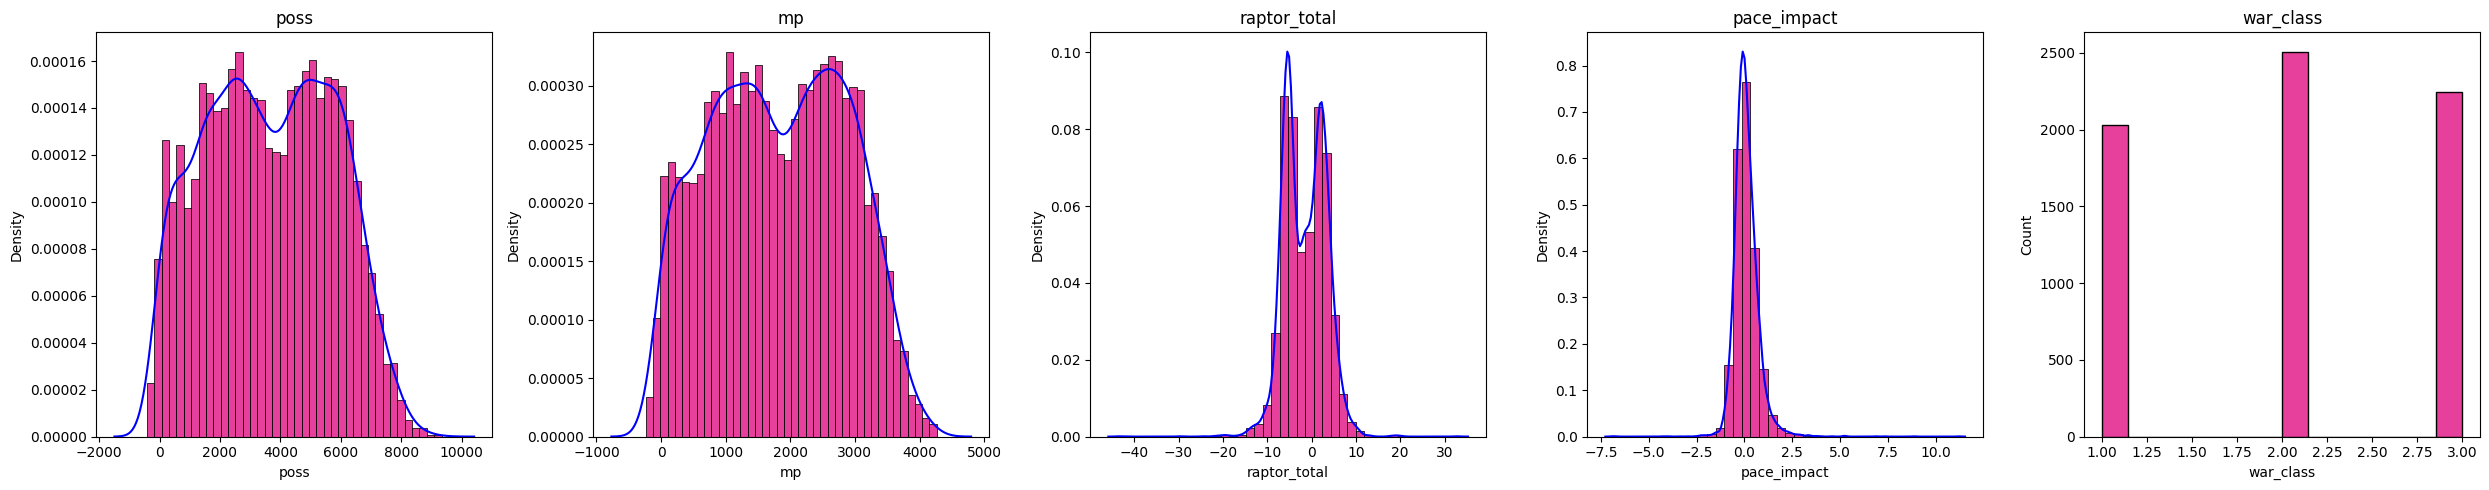

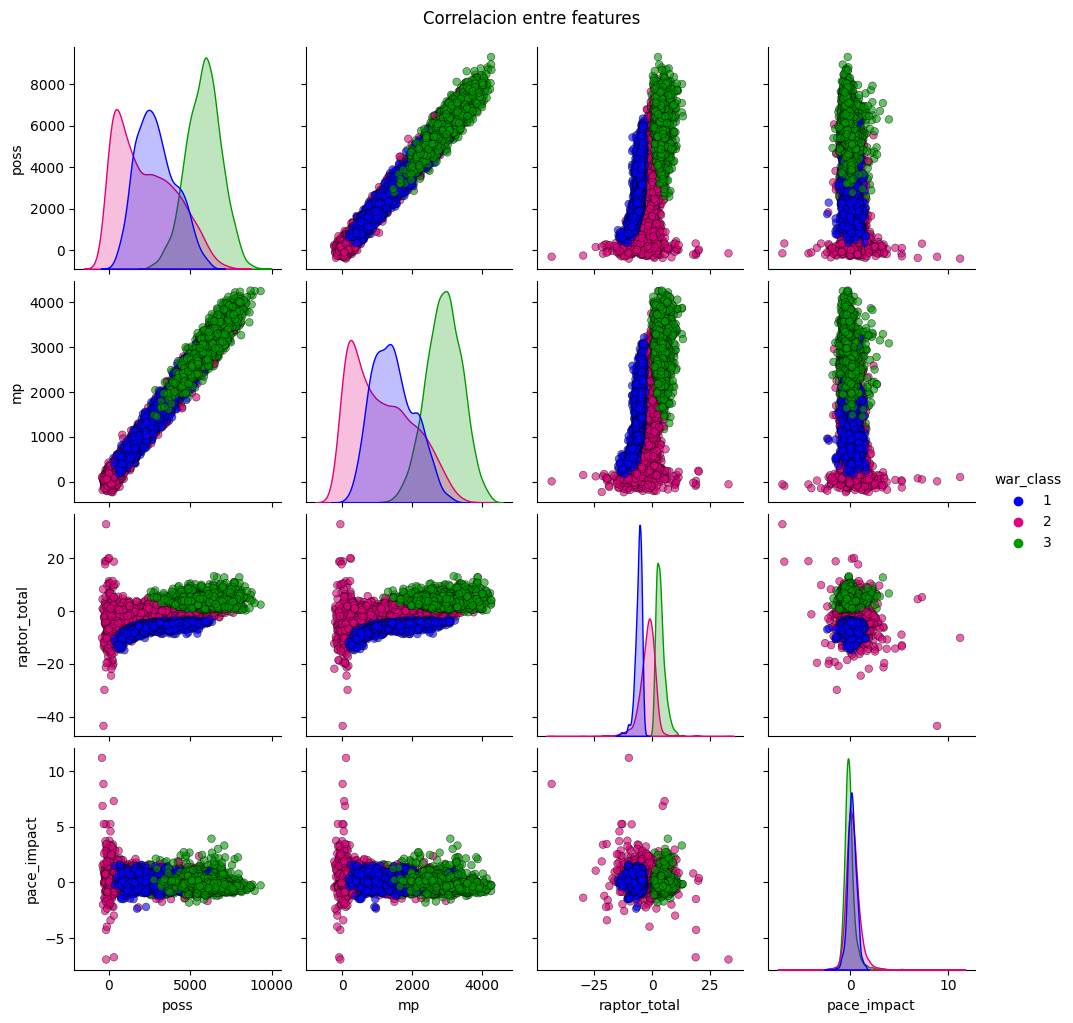

In [3]:
categoricas = ["war_class"]
features = list(data.columns)
fig, axes = plt.subplots(1, len(features), figsize=(5 * len(features), 5))
axes = axes.flatten()
#hago histograma y a las features categoricas no les dibujo la densidad.
for i, feature in enumerate(features):
    es_numerica = feature not in categoricas
    if es_numerica:
        sns.histplot(data[feature], bins=40, ax=axes[i],
                     color=(224/255, 0, 123/255), stat="density")
        sns.kdeplot(data[feature], ax=axes[i], color=(0.0, 0.0, 1.0))
    else:
        sns.histplot(data[feature], ax=axes[i],
                     color=(224/255, 0, 123/255), stat="count")
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

#analizo correlaciones
colores = [(0.0, 0.0, 1.0),(224/255, 0, 123/255),(0.0, 0.6, 0.0)]

num_cols = [c for c in data.columns if c not in categoricas]

sns.pairplot(data,vars=num_cols,diag_kind="kde",hue="war_class",palette=colores,plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'})
plt.suptitle("Correlacion entre features", y=1.02)
plt.show()



In [4]:
#correlacion de las features con el target
data_corr = data.copy()

corr_with_war = data_corr.corr()["war_class"].drop("war_class").sort_values(ascending=False)

print("\nCorrelacion de cada feature con el target:")
print(corr_with_war.to_string())

#matriz de correlacion entre features
num_cols = data.select_dtypes(include='number').columns
corr_matrix = data[num_cols].corr().round(2)
print("Matriz de correlación completa:\n")
print(corr_matrix.to_string())



Correlacion de cada feature con el target:
raptor_total    0.810724
mp              0.567405
poss            0.564286
pace_impact    -0.168358
Matriz de correlación completa:

              poss    mp  raptor_total  pace_impact  war_class
poss          1.00  0.98          0.64        -0.34       0.56
mp            0.98  1.00          0.65        -0.34       0.57
raptor_total  0.64  0.65          1.00        -0.26       0.81
pace_impact  -0.34 -0.34         -0.26         1.00      -0.17
war_class     0.56  0.57          0.81        -0.17       1.00


Dividir el dataset de desarrollo en un 80 % para entrenamiento y un 20 % para
validación. Estos conjuntos se utilizarán en las siguientes etapas para entrenar y
evaluar los modelos. Aplicar las técnicas de limpieza y preprocesamiento que considere necesarias, justificando sus decisiones. Recuerde que algunos de los modelos
a utilizar pueden beneficiarse de técnicas de normalización de datos.

In [5]:
#elimino filas con valores negativos en 'poss' y 'mp' ya que no tienen sentido
data_clean = data[(data['poss'] >= 0) & (data['mp'] >= 0)]

#split 
X_train, X_val, y_train, y_val = split_val_train(
    data_clean, target_column='war_class', test_size=0.2
)
train_df = pd.concat([X_train, y_train], axis=1)
val_df = pd.concat([X_val, y_val], axis=1)

In [6]:
#armo segundo posible dataset eliminando la feature 'poss' ya que tiene alta correlacion con poss
train_sincolinealidad = train_df.drop(columns=['poss']).copy()
val_sincolinealidad = val_df.drop(columns=['poss']).copy()

#armo tercer posible dataset agregando nuevas features y eliminando poss y mp ya que una nueva feature es una combinacion de estos.
train_features = train_df.copy()
val_features = val_df.copy()

for df in [train_features, val_features]:
    df['poss_per_min'] = df['poss'] / df['mp']
    df['raptor_total_impact'] = df['raptor_total'] * df['poss']
    df['raptor_per_min'] = df['raptor_total'] / df['mp']
    df.drop(columns=['poss', 'mp','pace_impact'], inplace=True)

#normalizo los datasets
num_cols = [c for c in train_df.select_dtypes(include='number').columns if c != 'war_class']
means = train_df[num_cols].mean()
stds = train_df[num_cols].std()
train_df_norm = train_df.copy()
train_df_norm[num_cols] = (train_df[num_cols] - means) / stds.replace(0, 1)  # evito div/0
val_df_norm = val_df.copy()
val_df_norm[num_cols] = (val_df[num_cols] - means) / stds.replace(0, 1)

num_cols = [c for c in train_sincolinealidad.select_dtypes(include='number').columns if c != 'war_class']
means = train_sincolinealidad[num_cols].mean()
stds = train_sincolinealidad[num_cols].std()

train_sincol_norm = train_sincolinealidad.copy()
train_sincol_norm[num_cols] = (train_sincolinealidad[num_cols] - means) / stds.replace(0, 1)

val_sincol_norm = val_sincolinealidad.copy()
val_sincol_norm[num_cols] = (val_sincolinealidad[num_cols] - means) / stds.replace(0, 1)


num_cols = [c for c in train_features.select_dtypes(include='number').columns if c != 'war_class']
means = train_features[num_cols].mean()
stds = train_features[num_cols].std()

train_features_norm = train_features.copy()
train_features_norm[num_cols] = (train_features[num_cols] - means) / stds.replace(0, 1)

val_features_norm = val_features.copy()
val_features_norm[num_cols] = (val_features[num_cols] - means) / stds.replace(0, 1)



En un primer enfoque, se opto por eliminar los valores que no tenían sentido o eran claramente erroneos, con el objetivo de depurar el dataset y evitar que estos datos afectaran negativamente al entrenamiento de los modelos.
Posteriormente, tras analizar las correlaciones entre las variables, se observó que las columnas poss y mp presentaban una alta correlacion entre si, lo que podría inducir colinealidad en el modelo, la cual podria afectar la capacidad predictiva del modelo. Por este motivo, se decidio eliminar 'poss'.
En un tercer enfoque, se agregaron nuevas columnas construidas como combinaciones de variables existentes, con el fin de capturar mas efectos no lineales. Al mismo tiempo, se elimino poss y mp para evitar problemas de redundancia y colinealidad, asegurando que las nuevas características aportaran información relevante sin generar dependencia excesiva entre variables.

Implementar y entrenar los siguientes tres modelos de clasificación:
1) Análisis Discriminante Lineal (LDA).
2) Regresión logística multiclase (con posibilidad de incluir regularización).
3) Bosque aleatorio (Random Forest), utilizando entropía como criterio de división. Se recomienda experimentar con distintos hiperparámetros (número de
árboles, profundidad máxima, etc.) y seleccionar la mejor configuración en
base a los resultados obtenidos.


Evaluacion para train_df_norm ===
Dataset: train_df_norm

Matriz de Confusion:
[[366   3   0]
 [ 66 346  65]
 [  0   0 471]]
Accuracy LDA: 0.8983


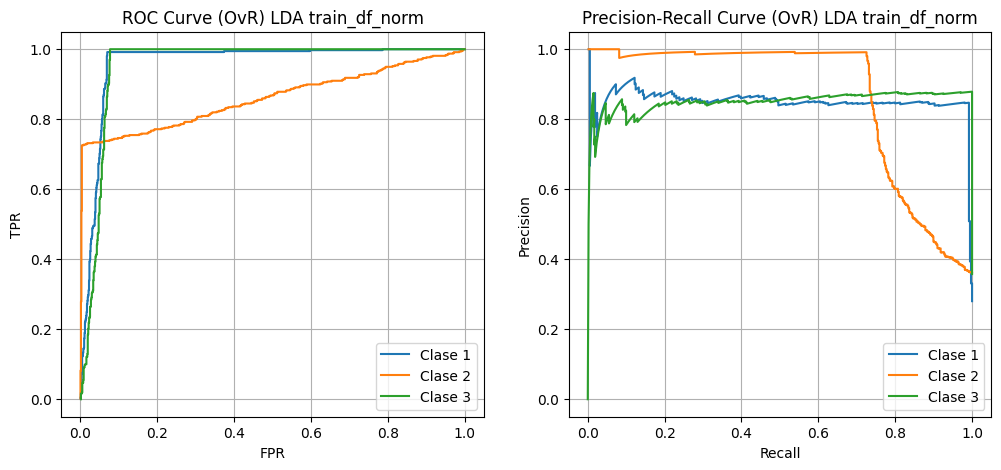


=== Evaluacion LogReg: train_df_norm ===

Matriz de Confusion:
[[359  10   0]
 [ 44 400  33]
 [  0   2 469]]
Accuracy Regresion: 0.9324


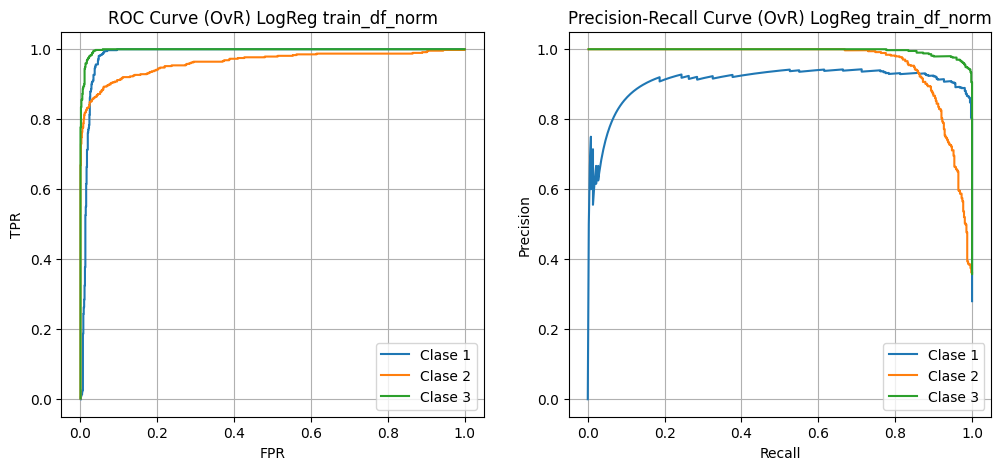


=== Evaluación RF: train_df_norm ===

Matriz de Confusion:
[[364   5   0]
 [ 38 420  19]
 [  0   6 465]]
Accuracy Random Forest: 0.9484


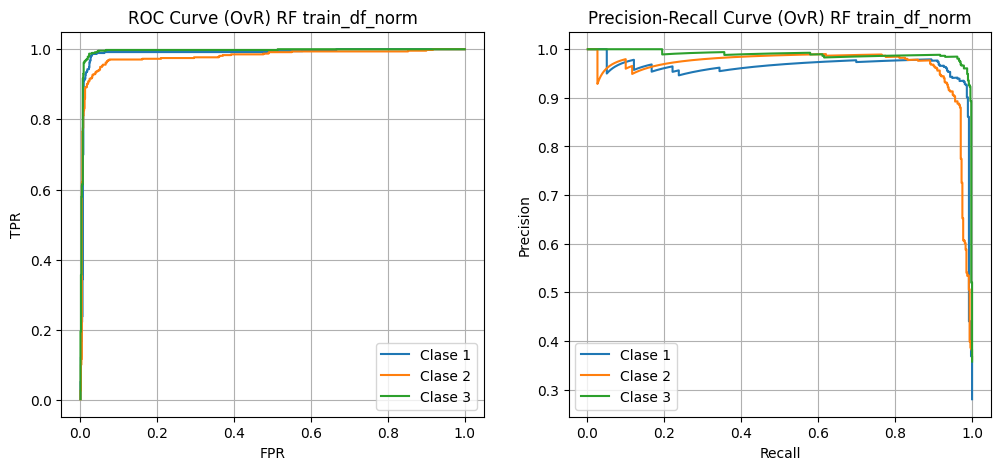


Evaluacion para train_sincol_norm ===
Dataset: train_sincol_norm

Matriz de Confusion:
[[366   3   0]
 [ 66 343  68]
 [  0   0 471]]
Accuracy LDA: 0.8960


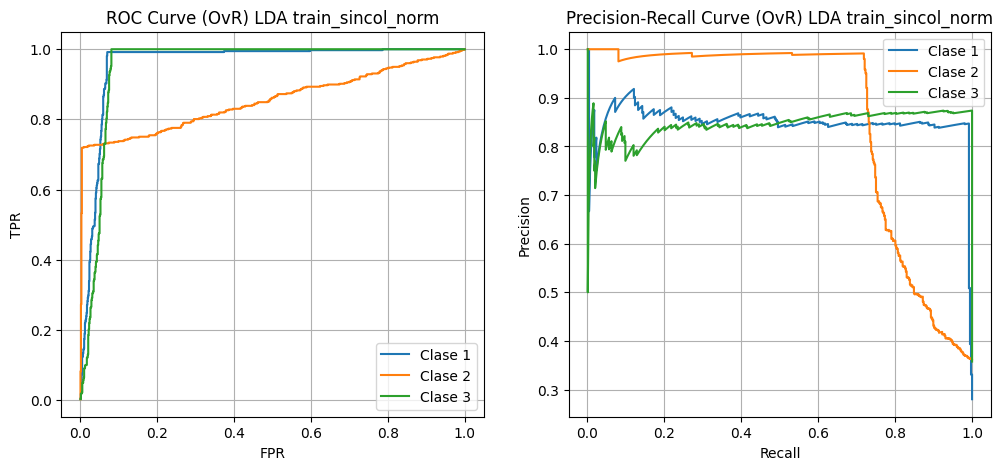


=== Evaluacion LogReg: train_sincol_norm ===

Matriz de Confusion:
[[357  12   0]
 [ 44 401  32]
 [  0   3 468]]
Accuracy Regresion: 0.9309


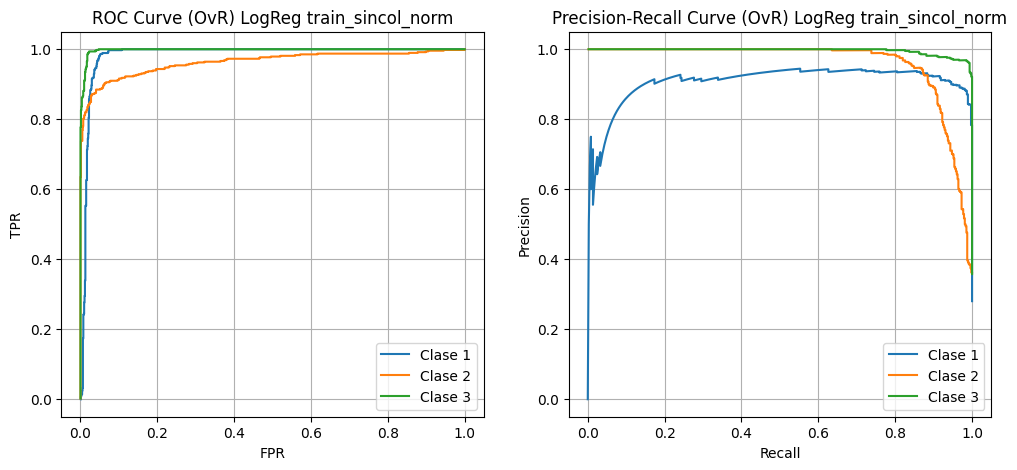


=== Evaluación RF: train_sincol_norm ===

Matriz de Confusion:
[[362   7   0]
 [ 43 412  22]
 [  0   9 462]]
Accuracy Random Forest: 0.9385


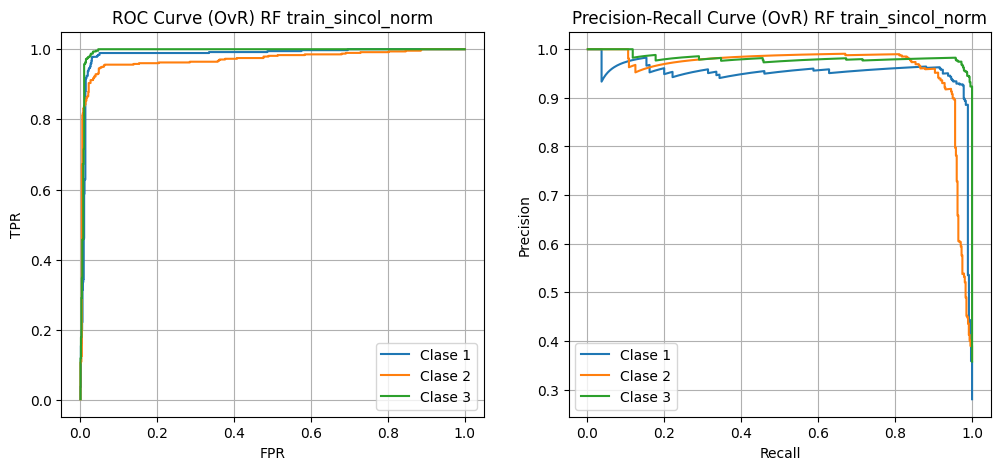


Evaluacion para train_features_norm ===
Dataset: train_features_norm

Matriz de Confusion:
[[367   2   0]
 [ 78 368  31]
 [  0  40 431]]
Accuracy LDA: 0.8853


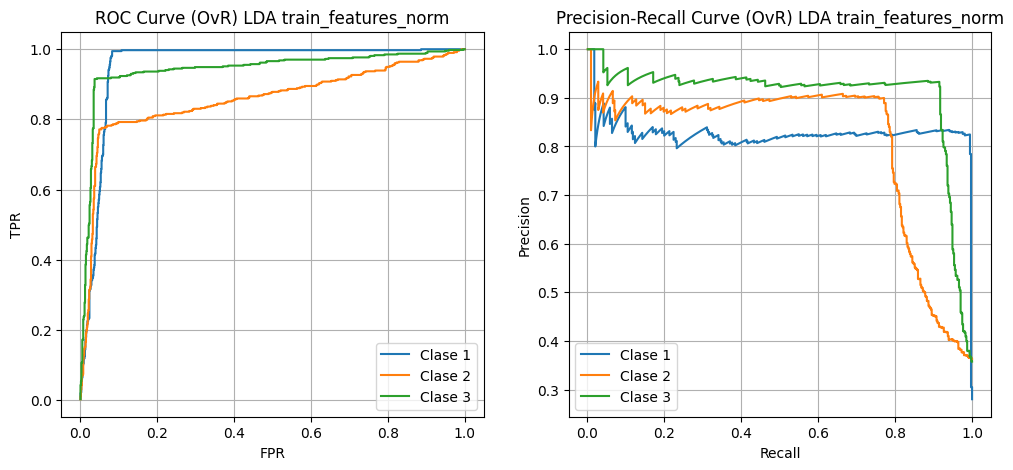


=== Evaluacion LogReg: train_features_norm ===

Matriz de Confusion:
[[367   2   0]
 [ 37 403  37]
 [  0  29 442]]
Accuracy Regresion: 0.9203


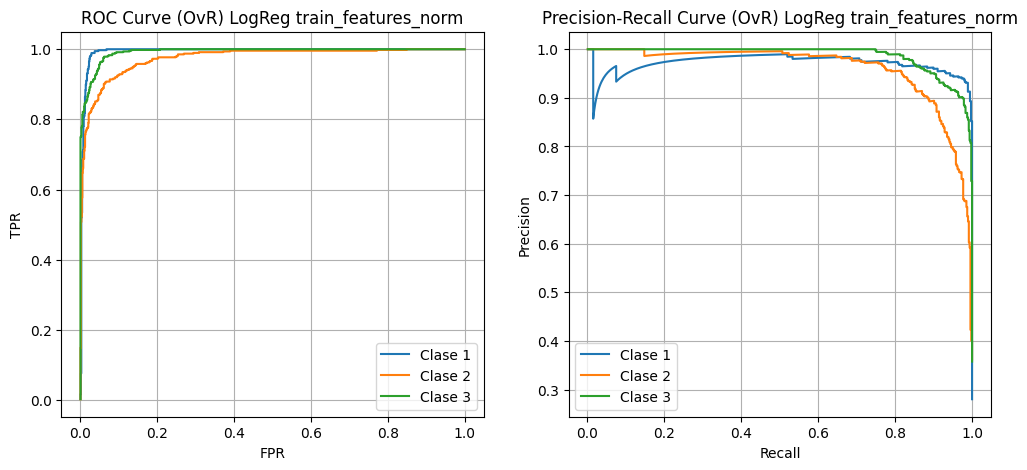


=== Evaluación RF: train_features_norm ===

Matriz de Confusion:
[[363   6   0]
 [ 24 440  13]
 [  0  17 454]]
Accuracy Random Forest: 0.9544


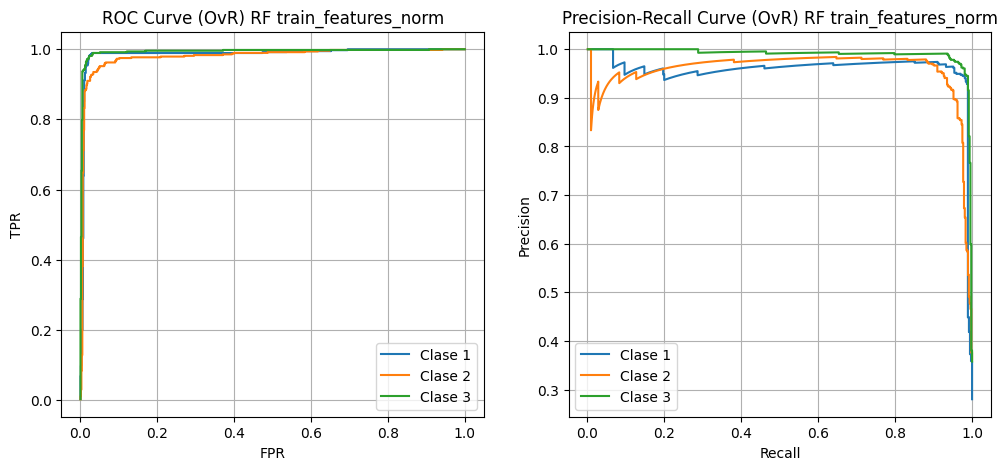

In [7]:
all_datasets = {
    "train_df_norm": (train_df_norm, val_df_norm),
    "train_sincol_norm": (train_sincol_norm, val_sincol_norm),
    "train_features_norm": (train_features_norm, val_features_norm),
}
resultados_completos = {}

for name, (train, val) in all_datasets.items():
    print(f"\nEvaluacion para {name} ===")
    X_train = train.drop(columns=['war_class']).to_numpy()
    y_train = train['war_class'].to_numpy().astype(int)
    X_val = val.drop(columns=['war_class']).to_numpy()
    y_val = val['war_class'].to_numpy().astype(int)

    resultados_completos[name] = {}
    resultados_completos[name]['LDA'] = entrenar_LDA(X_train, y_train, X_val, y_val, name)
    resultados_completos[name]['LogReg'] = entrenar_logreg(X_train, y_train, X_val, y_val, name)
    resultados_completos[name]['RF'] = entrenar_RF(X_train, y_train, X_val, y_val, name)

In [8]:
for dataset_name, res in resultados_completos.items():
    print(f"\nMetricas completas por clase: {dataset_name}")
    for modelo, metrics in res.items():
        print(f"\n--- {modelo} ---")
        df = pd.DataFrame(metrics).T  
        df.index.name = "Clase"
        display(df)


Metricas completas por clase: train_df_norm

--- LDA ---


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.921916,0.961125,0.941112,0.961348,0.848316
2,0.928037,0.860898,0.893207,0.860165,0.864040
3,0.939366,0.961584,0.950345,0.956132,0.850347



--- LogReg ---


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.939939,0.963243,0.951448,0.983677,0.904297
2,0.942895,0.912144,0.927265,0.963040,0.957321
3,0.965904,0.978373,0.972099,0.997879,0.993971



--- RF ---


...

,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.911213,0.956151,0.933141,0.956365,0.824914
2,0.888692,0.860744,0.874495,0.857864,0.807256
3,0.943058,0.939216,0.941133,0.943175,0.904708



--- LogReg ---


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.953113,0.977775,0.965286,0.993994,0.968445
2,0.922383,0.903979,0.913089,0.974693,0.958767
3,0.944075,0.947347,0.945708,0.992587,0.985024



--- RF ---


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.965766,0.979212,0.972443,0.986756,0.956309
2,0.953499,0.947525,0.950503,0.979849,0.953636
3,0.976081,0.974270,0.975175,0.993836,0.987987


Reentrenar cada modelo utilizando el dataset completo de desarrollo
WAR_class_dev.csv y evaluar su desempeño sobre el conjunto de test
WAR_class_test.csv, reportando las métricas anteriores.

Dataset: WAR_class

Matriz de Confusion:
[[480   3   0]
 [ 76 476  79]
 [  0   3 579]]
Accuracy LDA: 0.9051


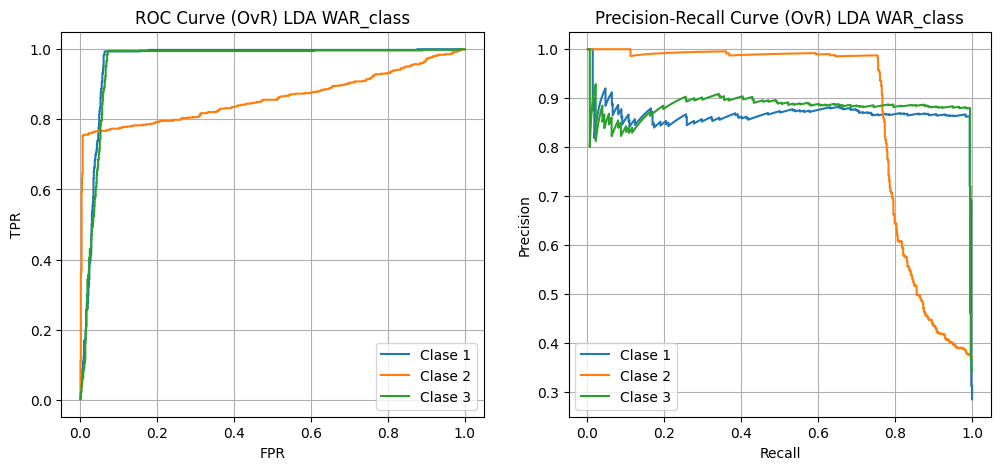


=== Evaluacion LogReg: WAR_class ===

Matriz de Confusion:
[[469  14   0]
 [ 64 523  44]
 [  0  13 569]]
Accuracy Regresion: 0.9204


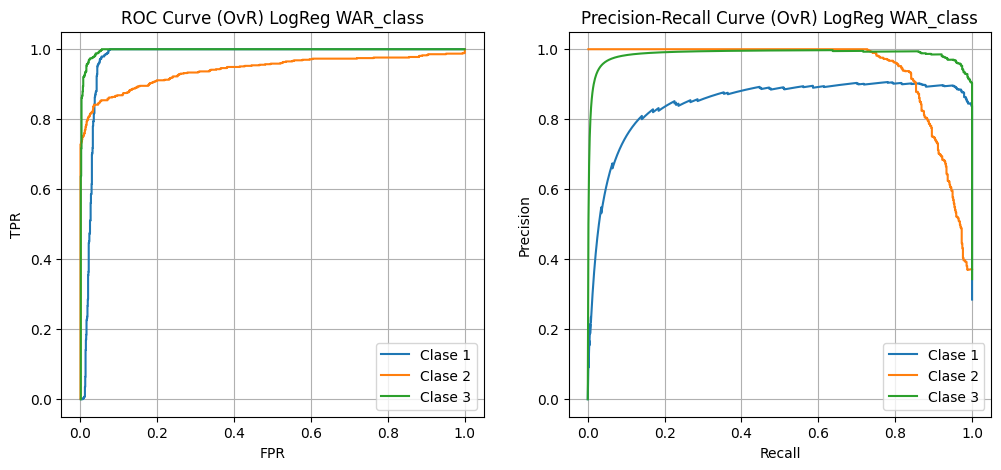


=== Evaluación RF: WAR_class ===

Matriz de Confusion:
[[482   1   0]
 [ 32 576  23]
 [  0  12 570]]
Accuracy Random Forest: 0.9599


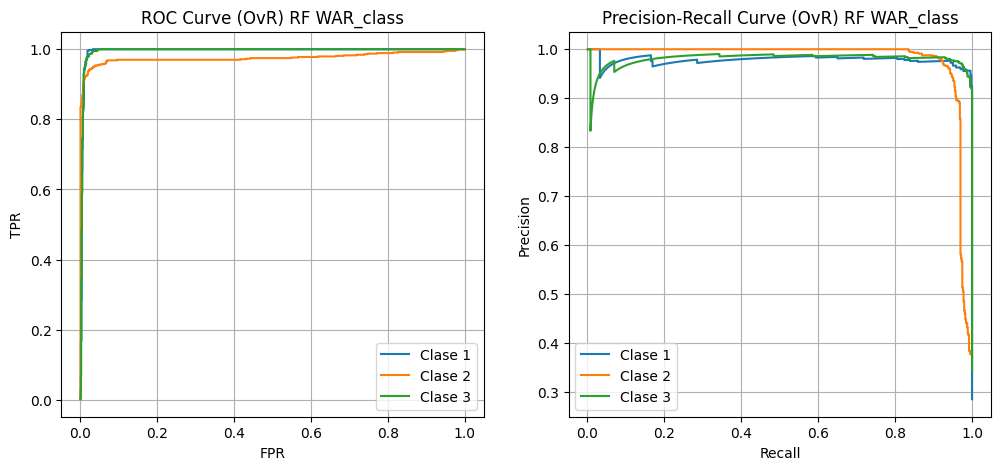


 Métricas completas por clase: WAR_class)

 Metricas: LDA 


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.930339,0.965567,0.947626,0.967486,0.864684
2,0.929937,0.874362,0.901294,0.861220,0.876264
3,0.938525,0.961965,0.950100,0.962443,0.879378



 Metricas: LogReg 


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.933944,0.959126,0.946367,0.973626,0.844216
2,0.928334,0.901745,0.914847,0.941725,0.941384
3,0.958109,0.969083,0.963565,0.996547,0.983901



 Metricas: RF 


,precision,recall,f1,auc_roc,auc_pr
Clase,,,,,
1,0.968449,0.985774,0.977035,0.995424,0.976221
2,0.964122,0.950315,0.957169,0.975752,0.978029
3,0.975167,0.979368,0.977263,0.995390,0.979155


In [9]:
train_df = pd.read_csv('data/raw/WAR_class_dev.csv')
test_df  = pd.read_csv('data/raw/WAR_class_test.csv')

num_cols = [c for c in train_df.select_dtypes(include='number').columns if c != 'war_class']
means = train_df[num_cols].mean()
stds  = train_df[num_cols].std().replace(0, 1)
train_df[num_cols] = (train_df[num_cols] - means) / stds
test_df[num_cols]  = (test_df[num_cols] - means) / stds

X_train = train_df.drop(columns=['war_class']).to_numpy()
y_train = train_df['war_class'].to_numpy().astype(int)
X_test  = test_df.drop(columns=['war_class']).to_numpy()
y_test  = test_df['war_class'].to_numpy().astype(int)

resultados_final = {}
resultados_final['LDA'] = entrenar_LDA(X_train, y_train, X_test, y_test, dataset_name="WAR_class")
resultados_final['LogReg'] = entrenar_logreg(X_train, y_train, X_test, y_test, dataset_name="WAR_class")
resultados_final['RF'] = entrenar_RF(X_train, y_train, X_test, y_test, dataset_name="WAR_class")

print("\n Métricas completas por clase: WAR_class)")
for modelo, metrics in resultados_final.items():
    print(f"\n Metricas: {modelo} ")
    df = pd.DataFrame(metrics).T 
    df.index.name = "Clase"
    display(df)


Analizar los resultados obtenidos y discutir cuál de los modelos sería más adecuado para un entorno de producción. Justificar la elección en base a las métricas
observadas y al comportamiento de los modelos. Compare además los resultados
de validación (inciso 2.4) con los obtenidos en test (inciso 2.5). ¿Son similares?
¿Las métricas de validación resultaron buenas estimadoras de la performance en
test?


Al comparar los modelos, Random Forest obtuvo las mejores metricas tanto en validacion como en test, debido a su capacidad para manejar relaciones no lineales. Igualmente, los tres modelos dieron metricas satisfactorias (arriba de 0.8 en accuracy y arriba de 0.9 en F1 para todas las clases).
Los resultados de validacion y test fueron muy similares, lo que indica que las metricas de validacion estimaron bien la performance en datos no vistos. LDA mostro rendimientos algo menores, la regresion logistica mantuvo un desempeño intermedio entre ambos conjuntos, y Random Forest destaco con las mejores metricas en validacion y las replico casi sin cambios en test. En conjunto, no se observo sobreajuste significativo y la validacion resulto un buen predictor del rendimiento final.